# 03: The model against the market

**The question this notebook answers:** does a calibrated forecast of the day's high beat the
market's prices, and when?

The forecasts are public: ECMWF, GFS and the GEFS ensemble, pulled from the open archives with the
time each file appeared. The model is a regression of the day's high on those three numbers with a
spread that grows with the ensemble spread, refit every day on the last 90 days, and turned into a
probability per bucket. It is scored point in time against the market price at the same moment.
This notebook runs that chain for London at noon. The package function `run_station` is the same
one `make train` calls for every city.

**The answer it arrives at:** two days before the day, yes. The model is 0.042 Brier better than the
market on the buckets where the two disagree, with an interval well above zero. One day before,
the two are level. On the day itself the market is far ahead, even when the model reads the
morning's reports. And the whole two-days-out edge is one thing: the market's favourite bucket is
priced too high that early.

## Setup

In [1]:
import json

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from weather_edge import config
from weather_edge import model as m
from weather_edge.market_checks import STATION_TZ

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

STATION = "EGLC"
TZ = STATION_TZ[STATION]

con = duckdb.connect(str(config.RESEARCH_DB), read_only=True)
con.execute("SET enable_progress_bar=false")
con.execute(f"ATTACH '{config.PRICES_DB}' AS px (READ_ONLY)")
con.execute(f"ATTACH '{config.FORECASTS_DB}' AS fc (READ_ONLY)")

def q(sql, params=None):
    return con.execute(sql, params or []).df()

## Which forecast may a decision use?

**A forecast can be used from the moment its file appeared, not from the run's nominal time.** The
00Z ECMWF run is labelled midnight, but its file shows up on the open-data mirror a median 7.6
hours later. GFS takes 3.8 hours, GEFS 4.1. The extractor stores each file's Last-Modified header as
its availability time, and a run counts at a decision only if every step inside the local day was
public before it.

Here is what that means for one decision: noon in London on 28 July 2026, two days before the
30th. The table lists the runs that cover the 30th, when each became public, and its forecast high.

In [2]:
decision = pd.Timestamp("2026-07-28 11:00")  # noon London in summer, in UTC

runs = q("""
    SELECT model, init_time, max(available_time) AS public_at, count(*) AS steps_in_day,
           round(max(temp_c), 1) AS forecast_high_c
    FROM fc.forecasts
    WHERE station = 'EGLC' AND model IN ('ecmwf', 'gfs', 'gefs_mean')
      AND init_time >= TIMESTAMP '2026-07-27 12:00' AND init_time <= TIMESTAMP '2026-07-28 12:00'
      AND valid_time >= TIMESTAMP '2026-07-29 23:00' AND valid_time < TIMESTAMP '2026-07-30 23:00'
    GROUP BY 1, 2
    ORDER BY 1, 2
""")
runs["usable_at_noon"] = runs.public_at <= decision
runs

,model,init_time,public_at,steps_in_day,forecast_high_c,usable_at_noon
0,ecmwf,2026-07-27 12:00:00,2026-07-27 19:34:42,5,25.0,True
1,ecmwf,2026-07-27 18:00:00,2026-07-28 00:27:42,7,26.8,True
2,ecmwf,2026-07-28 00:00:00,2026-07-28 07:34:43,8,26.8,True
3,ecmwf,2026-07-28 06:00:00,2026-07-28 12:28:36,8,27.0,False
4,ecmwf,2026-07-28 12:00:00,2026-07-28 19:34:39,8,26.9,False
5,gefs_mean,2026-07-27 12:00:00,2026-07-27 16:23:00,5,25.4,True
6,gefs_mean,2026-07-27 18:00:00,2026-07-27 22:21:19,7,27.2,True
7,gefs_mean,2026-07-28 00:00:00,2026-07-28 04:18:25,8,27.1,True
8,gefs_mean,2026-07-28 06:00:00,2026-07-28 10:15:01,8,26.8,True
9,gefs_mean,2026-07-28 12:00:00,2026-07-28 16:14:09,8,27.2,False


In [3]:
features = m.features(con, STATION, TZ, decision_hour=12)

print(len(features), "rows: one per day and lead")
features[(features.day == "2026-07-30") & (features.lead == 3)][
    ["day", "lead", "t", "ecmwf", "gfs", "gefs_mean", "gefs_spread"]
]

1911 rows: one per day and lead


,day,lead,t,ecmwf,gfs,gefs_mean,gefs_spread
1724,2026-07-30,3,2026-07-28 11:00:00,26.769633,28.738623,26.79108,1.604


### What we got

At 11:00 UTC the ECMWF 06Z run is not public yet. It appears at 12:28, 88 minutes after the
decision. So the feature row uses the 00Z run for ECMWF (26.8 °C) and the 06Z runs for GFS and
GEFS, which were out by 10:15. A pipeline keyed to nominal run times would have used a forecast
that did not exist. That is the difference between a backtest and a story.

The features table has one row per day and lead: the forecast high of each source from its newest
usable run, and the GEFS spread at the hour of its maximum. Days come from the label table, not
from the market, so every day trains the model whether or not a market existed.

## The three models

Everything is refit every day on a trailing window, using only labels of days that had ended by
the decision.

- **clim**: a normal fit to the last 30 days of highs. The floor.
- **raw**: the three forecast highs averaged, with their disagreement as the spread and a floor of
  2 °C. What you get from reading the forecasts and not modelling anything.
- **emos**: the day's high regressed on the three forecast highs, with a spread that has a constant
  part and a part that grows with the GEFS spread, and a Student t shape. All parameters are
  fitted at once by minimising the CRPS over the last 90 days. The spread is then multiplied by
  the root mean square of the last 90 out-of-sample errors, for a reason shown below.
- **obs**: same day only. By noon some of the day's reports are in, so the final high is the larger
  of the running maximum and a draw from a regression on the remaining forecast hours and the
  last report. That is a censored regression.

This cell fits all of them for London at noon, for one, two and three days out. It takes about
eight minutes.

In [4]:
result = m.run_station(con, STATION, decision_hour=12)

result["coverage"]

,station,decision_hour_local,period,feature_days,label_days,sources_with_coverage,obs_days,share_max_before_decision,market_buckets
0,EGLC,12,before 2026-08-01,577,577,"[ecmwf, gfs, gefs_mean, gefs_spread]",577,0.063657,11447


In [5]:
scores = result["continuous"]
scores[["lead", "model", "days", "crps", "mae", "mean_sigma", "coverage_90"]].round(3)

,lead,model,days,crps,mae,mean_sigma,coverage_90
0,1,clim,567,2.139,3.004,3.306,0.841
1,1,raw,577,0.757,0.996,2.106,0.995
2,1,emos,557,0.566,0.762,1.058,0.912
3,1,obs,557,0.489,0.686,0.935,0.892
4,2,clim,566,2.216,3.082,3.307,0.829
5,2,raw,576,0.826,1.121,2.140,0.991
6,2,emos,555,0.661,0.887,1.225,0.908
7,3,clim,565,2.278,3.148,3.307,0.812
8,3,raw,574,0.895,1.238,2.174,0.983
9,3,emos,552,0.745,0.986,1.342,0.924


### What we got

**CRPS, in °C, from the raw forecasts to the model:** two days out the average of the three
forecasts scores 0.89 and the model 0.74. One day out 0.83 against 0.66. On the day 0.76 against
0.57, and 0.49 once the model reads the morning's reports. Climatology is at 2.1 to 2.3, so the
forecasts carry almost all the information and the modelling adds a fifth on top.

The `coverage_90` column is the share of days whose high fell inside the model's 90% interval. For
the model it is 91 to 92%. That number is the reason for the calibration step.

## Is the spread honest?

**The first version of the model was too sure of itself.** Its nominal 90% interval covered 82% of
days and the PIT histogram was U-shaped. Switching the shape from normal to Student t did not fix
it: the degrees of freedom ran to the upper bound, because the errors are not heavy-tailed. The fit
is simply overconfident about a window that keeps moving.

What fixed it was measuring the overconfidence out of sample. Each day the spread is scaled by the
root mean square of the last 90 standardised errors that were known at the decision. The PIT is
the probability the model gave to a high at or below the one that happened. If the spread is
right, those values are uniform.

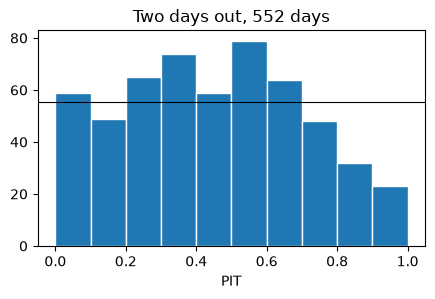

90% interval coverage: 0.924
calibration scale, median: 1.32 | range: 1.0 to 1.82


In [6]:
walk = result["wf"]
two_days = walk[(walk.lead == 3)].dropna(subset=["emos_mu", "y"])

pit = np.array([float(m.cdf(row.y, row.emos_mu, row.emos_sigma, row.emos_nu)) for row in two_days.itertuples()])
lower = np.array([m.ppf(0.05, mu, sigma, nu) for mu, sigma, nu in zip(two_days.emos_mu, two_days.emos_sigma, two_days.emos_nu)])
upper = np.array([m.ppf(0.95, mu, sigma, nu) for mu, sigma, nu in zip(two_days.emos_mu, two_days.emos_sigma, two_days.emos_nu)])

fig, ax = plt.subplots(figsize=(5, 2.8))
ax.hist(pit, bins=10, range=(0, 1), edgecolor="white")
ax.axhline(len(pit) / 10, color="black", linewidth=0.8)
ax.set_xlabel("PIT")
ax.set_title(f"Two days out, {len(pit)} days")
plt.show()

print("90% interval coverage:", round(float(((two_days.y >= lower) & (two_days.y <= upper)).mean()), 3))
print("calibration scale, median:", round(float(two_days.emos_scale.median()), 2),
      "| range:", round(float(two_days.emos_scale.min()), 2), "to", round(float(two_days.emos_scale.max()), 2))

### Roughly flat, with a thin top

The histogram is close to flat and the 90% interval covers 92% of days. The in-sample fit needed
its spread stretched by a third (median scale 1.32) to get there. The one feature left is the thin
top: fewer days than expected land above the model's 80th percentile. Two days out the model leans
slightly warm. It is small, and I left it, because fixing it in sample is how the first version
went wrong.

The calibration cost 0.01 °C of CRPS and moved the market comparison by less than 0.002. It is not
there to win, it is there so that a probability of 0.3 means 0.3.

## Against the market

**Every resolved bucket with a price at the decision, scored both ways.** The market's Brier score
and the model's on all buckets, then the difference on the buckets where the two disagree by 10c or
more, with a bootstrap over days. Days rather than buckets, because the seven buckets of one day
share one outcome. Positive means the model did better.

In [7]:
market = result["market"]
market[["lead", "model", "buckets", "days", "brier_market", "brier_model", "n_disagree",
        "market_minus_model_on_disagree", "ci_low", "ci_high"]].round(4)

,lead,model,buckets,days,brier_market,brier_model,n_disagree,market_minus_model_on_disagree,ci_low,ci_high
0,1,clim,4028,548,0.0729,0.1487,2045,-0.1469,-0.1595,-0.1344
1,1,raw,4028,548,0.0729,0.1072,1897,-0.0682,-0.0772,-0.0597
2,1,emos,4028,548,0.0729,0.0937,1341,-0.0607,-0.0724,-0.0489
3,1,obs,4028,548,0.0729,0.0874,1046,-0.0544,-0.0690,-0.0392
4,2,clim,4301,530,0.0866,0.1387,2210,-0.0992,-0.1081,-0.0904
5,2,raw,4301,530,0.0866,0.1001,1812,-0.0292,-0.0354,-0.0226
6,2,emos,4301,530,0.0866,0.0899,1085,-0.0091,-0.0198,0.0005
7,3,clim,3118,365,0.1019,0.1302,1723,-0.0498,-0.0603,-0.0390
8,3,raw,3111,364,0.1019,0.0957,1338,0.0180,0.0089,0.0271
9,3,emos,3111,364,0.1019,0.0877,1087,0.0423,0.0313,0.0525


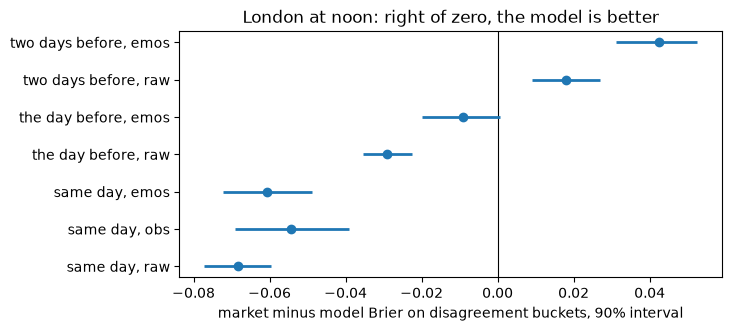

In [8]:
shown = market[market.model.isin(["raw", "emos", "obs"])].copy()
shown["label"] = shown.lead.map({3: "two days before", 2: "the day before", 1: "same day"}) + ", " + shown.model
shown = shown.sort_values(["lead", "model"], ascending=[False, True])

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.axvline(0, color="black", linewidth=0.8)
y = np.arange(len(shown))
ax.hlines(y, shown.ci_low, shown.ci_high, linewidth=2)
ax.plot(shown.market_minus_model_on_disagree, y, "o")
ax.set_yticks(y, shown.label)
ax.invert_yaxis()
ax.set_xlabel("market minus model Brier on disagreement buckets, 90% interval")
ax.set_title("London at noon: right of zero, the model is better")
plt.show()

### What we got

**Two days before the day the model is 0.042 better than the market, interval 0.031 to 0.053.** Even
the plain average of the three forecasts is ahead there, by 0.018, so half of the edge is just
that the forecasts are public and the market has not fully used them yet, and the other half is
the modelling. The day before, the model is level: −0.009 with an interval that touches zero. On
the day the market is 0.061 ahead of the forecast model and 0.054 ahead of the version that reads
the morning's reports.

The market's own Brier tells the same story from the other side: 0.102 two days out, 0.087 one day
out, 0.073 on the day. It gets a lot better in the last 24 hours, and the model does not.

## Where exactly the model wins

**Which buckets carry the edge?** Reliability of both forecasters on the same buckets two days out,
and then the disagreement buckets split by who was higher.

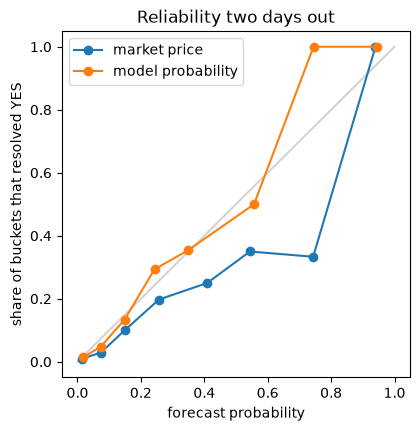

market                 model               
               mean_p hit_rate     n mean_p hit_rate     n
(-0.001, 0.05]  0.015    0.010  1196  0.018    0.015  1225
(0.05, 0.1]     0.074    0.029   277  0.073    0.047   467
(0.1, 0.2]      0.149    0.100   350  0.149    0.134   694
(0.2, 0.3]      0.257    0.198   496  0.243    0.293   501
(0.3, 0.5]      0.409    0.250   668  0.349    0.354   212
(0.5, 0.7]      0.544    0.350   120  0.557    0.500     6
(0.7, 0.9]      0.743    0.333     3  0.745    1.000     2
(0.9, 1.0]      0.940    1.000     1  0.945    1.000     4

In [9]:
scored = result["scored"]
two_days_scored = scored[scored.lead == 3].dropna(subset=["p_emos"])
edges = [0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0]

def reliability(p):
    band = pd.cut(p, edges, include_lowest=True)
    groups = two_days_scored.groupby(band, observed=True)
    return pd.DataFrame({"mean_p": p.groupby(band, observed=True).mean(),
                         "hit_rate": groups.outcome.mean(), "n": groups.size()})

model_reliability = reliability(two_days_scored.p_emos)
market_reliability = reliability(two_days_scored.market_p)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot([0, 1], [0, 1], color="lightgrey")
ax.plot(market_reliability.mean_p, market_reliability.hit_rate, marker="o", label="market price")
ax.plot(model_reliability.mean_p, model_reliability.hit_rate, marker="o", label="model probability")
ax.set_xlabel("forecast probability")
ax.set_ylabel("share of buckets that resolved YES")
ax.set_title("Reliability two days out")
ax.legend()
plt.show()

pd.concat({"market": market_reliability, "model": model_reliability}, axis=1).round(3)

In [10]:
disagree = two_days_scored[(two_days_scored.p_emos - two_days_scored.market_p).abs() >= 0.10].copy()
disagree["who_is_higher"] = np.where(disagree.p_emos > disagree.market_p, "model", "market")

def brier(p, outcome):
    return ((p - outcome) ** 2).mean()

by_side = disagree.groupby("who_is_higher").apply(lambda g: pd.Series({
    "buckets": len(g),
    "days": g.day.nunique(),
    "mean_market_price": g.market_p.mean(),
    "mean_model_probability": g.p_emos.mean(),
    "share_resolved_yes": g.outcome.mean(),
    "brier_market": brier(g.market_p, g.outcome),
    "brier_model": brier(g.p_emos, g.outcome),
}), include_groups=False)
by_side.astype({"buckets": int, "days": int}).round(3)

,buckets,days,mean_market_price,mean_model_probability,share_resolved_yes,brier_market,brier_model
who_is_higher,,,,,,,
market,914,325,0.384,0.143,0.183,0.193,0.139
model,173,126,0.108,0.270,0.145,0.096,0.113


### The market's favourite is priced too high two days out

**Buckets the market prices at 30 to 50c resolve YES 25% of the time. At 50 to 70c, 35%.** Two days
out the market is overconfident about its favourite bucket, and the model, whose probabilities stay
honest all the way up, is not.

The disagreement table says the same thing in money terms. On the 914 buckets where the market is
at least 10c above the model, the average price is 38c, the model says 14c, and 18% resolve YES. The
model is closer. On the 173 buckets where the model is above the market, the market is right:
those buckets resolve YES 14% of the time against the model's 27%.

So the edge is one thing, not a general one: fade the market's favourite two days out. Buying the
cheap buckets the model likes does not work. That is why notebook 04 finds all of its profit on the
NO side.

## The same day, with the thermometer

**By noon on the day the morning's reports are in, and on some days so is the high.** The same-day
model reads them. The final high is the larger of the running maximum and a draw from a regression
on the forecast for the remaining hours and the last report. On a day whose maximum is already in,
the running maximum is the answer and the regression is censored at it.

In [11]:
print("share of days whose high was already in by noon:",
      round(float(result["coverage"].share_max_before_decision.iloc[0]), 3))

same_day = market[market.lead == 1][["model", "brier_market", "brier_model",
                                     "market_minus_model_on_disagree", "ci_low", "ci_high"]]
same_day.round(4)

share of days whose high was already in by noon: 0.064


,model,brier_market,brier_model,market_minus_model_on_disagree,ci_low,ci_high
0,clim,0.0729,0.1487,-0.1469,-0.1595,-0.1344
1,raw,0.0729,0.1072,-0.0682,-0.0772,-0.0597
2,emos,0.0729,0.0937,-0.0607,-0.0724,-0.0489
3,obs,0.0729,0.0874,-0.0544,-0.0690,-0.0392


### It helps the model, and it does not close the gap

Reading the reports takes the same-day CRPS from 0.57 to 0.49 °C, and the market comparison from
−0.061 to −0.054. In New York, where the report has the same table, it closes about a third of the
gap. The market at noon knows more than the global runs plus the morning's reports. The obvious
explanation, that it reads higher-resolution guidance, was tested with the National Blend of Models
and moved every score by less than 0.002.

## New York, by decision hour

The same chain was run for New York at 06:00, 08:00, 10:00 and noon (`reports/phase5_emos.md`).
The earlier the decision, the bigger the two-days-out edge, and the fewer markets have a quote.

In [12]:
metrics = json.load(open(config.MODELS / "metrics.json"))

nyc = pd.DataFrame({hour: {name: entry["diff"] for name, entry in by_hour.items()}
                    for hour, by_hour in metrics["nyc_by_decision_hour"].items()}).T
nyc[["lead3_emos", "lead2_emos", "lead1_emos", "lead1_obs"]].round(3)

,lead3_emos,lead2_emos,lead1_emos,lead1_obs
06:00,0.037,-0.011,-0.050,-0.043
08:00,0.032,-0.016,-0.054,-0.044
10:00,0.017,-0.018,-0.054,-0.045
12:00,0.021,-0.018,-0.062,-0.041


In [13]:
con.close()

## What this notebook establishes

**The model is a good forecaster.** CRPS 0.74 °C two days out against 0.89 for the raw forecasts, a
flat PIT and 92% coverage of its 90% interval, after the spread is stretched by the out-of-sample
errors.

**It beats the market two days out and nowhere else.** +0.042 Brier on disagreement buckets in
London, +0.021 in New York, intervals above zero. Level the day before. Behind on the day, even
with the observations.

**The edge is the market's overpriced favourite.** Two days out, buckets priced above 30c resolve
less often than their price says. Everything the model wins, it wins by saying no to those. Notebook
04 asks what that is worth once someone has to fill the order.